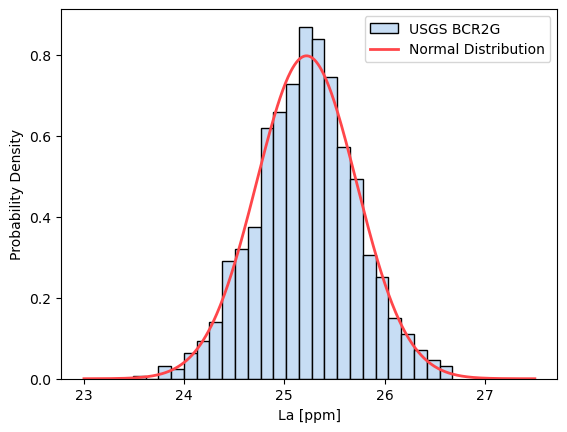

In [4]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np

my_dataset = pd.read_excel('USGS_BCR2G.xls', sheet_name='Sheet1')

fig, ax = plt.subplots()
ax.hist(my_dataset.La, bins='auto', density=True, edgecolor='#000000', color='#c7ddf4', label="USGS BCR2G")
ax.set_xlabel("La [ppm]")
ax.set_ylabel("Probability Density")

x = np.linspace(23,27.5,500)
pdf = stats.norm(loc=my_dataset.La.mean(), scale=my_dataset.La.std()).pdf(x)

ax.plot(x,pdf, linewidth=2, color='#ff464a', label='Normal Distribution')

ax.legend()


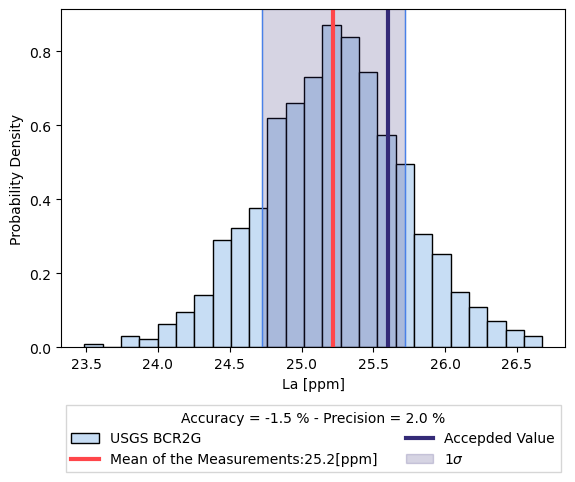

In [5]:
my_mean = my_dataset.La.mean()
R = 25.6
accuracy = 100 * (my_mean - R) / R
my_std = my_dataset.La.std()
precision = 100 * my_std / R

fig, ax = plt.subplots(figsize=(6,5))
ax.hist(my_dataset.La, bins = 'auto', density = True, edgecolor = '#000000', color = '#c7ddf4', label = 'USGS BCR2G')
ax.set_xlabel('La [ppm]')
ax.set_ylabel('Probability Density')

ax.axvline(x=my_dataset.La.mean(), color='#ff464a', linewidth=3, label='Mean of the Measurements:' + str(round(my_mean, 1)) + '[ppm]')
ax.axvline(x = R, color='#342a77', linewidth=3, label='Accepded Value')

ax.axvline(x = my_mean - my_std, color = '#4881e9', linewidth = 1)
ax.axvline(x = my_mean + my_std, color = '#4881e9', linewidth = 1)
ax.axvspan(my_mean - my_std,  my_mean + my_std, alpha = 0.2, color = '#342a77', label = r'$1\sigma$')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fancybox=False, shadow=False, ncol=2, title = 'Accuracy = {:.1f} % - Precision = {:.1f} %'.format(accuracy, precision))

fig.tight_layout()


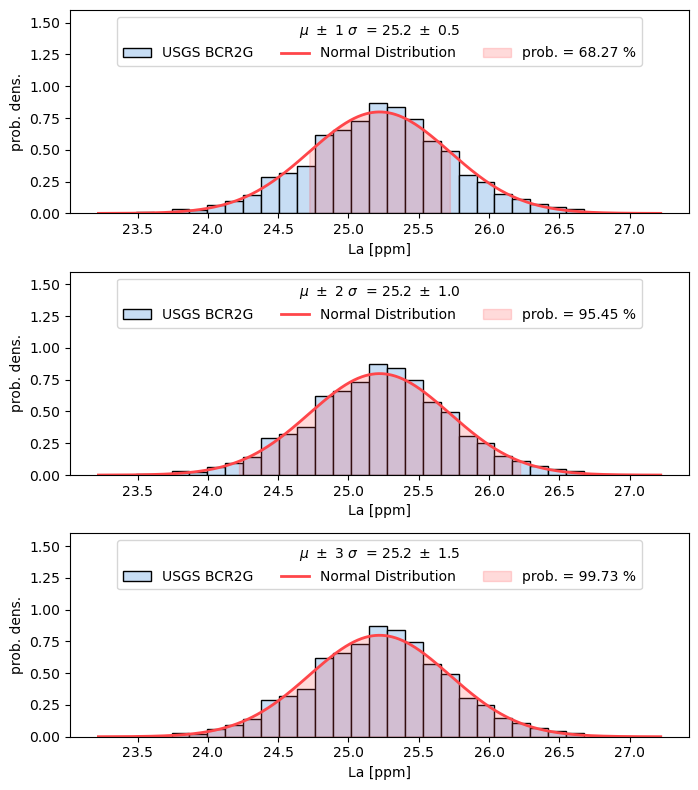

In [6]:
import numpy as np
import matplotlib.pyplot as plt


def normal_pdf(x, mu, sigma):
    pdf = 1/(sigma*np.sqrt(2*np.pi)) * np.exp(-(x-mu)**2 / (2*sigma**2))
    return pdf

signa_levels = [1, 2, 3]
confidences = [68.27, 95.45, 99.73]

fig = plt.figure(figsize=(7,8))

my_mean = my_dataset.La.mean()
my_std = my_dataset.La.std()

x_pdf = np.linspace(my_mean - 4 * my_std, my_mean + 4 * my_std, 1000)
my_pdf = normal_pdf(x_pdf, my_mean, my_std)

for signa_level, confidence in zip(signa_levels,confidences):
    ax = fig.add_subplot(3, 1, signa_level)
    ax.hist(my_dataset.La, bins='auto', density=True, edgecolor='#000000', color='#c7ddf4', label='USGS BCR2G', zorder=0)
    x_confidence = np.linspace(my_mean - signa_level * my_std, my_mean + signa_level * my_std, 1000)
    ax.plot(x_pdf, my_pdf, linewidth=2, color='#ff464a', label='Normal Distribution', zorder=1)
    ax.fill_between(x_confidence, normal_pdf(x_confidence, my_mean, my_std), y2=0, color='#ff464a', alpha=0.2, label='prob. = {}'.format(confidence) + ' %', zorder=1)
    ax.legend(ncol=3, loc='upper center', title=r'$\mu~ \pm ~$' + str(signa_level) + r'$ ~ \sigma ~ $ = ' + '{:.1f}'.format(my_mean) + r'$~ \pm ~$' + '{:.1f}'.format(signa_level * my_std))
    ax.set_ylim(0,1.6)
    ax.set_xlabel('La [ppm]')
    ax.set_ylabel('prob. dens.')

fig.tight_layout()

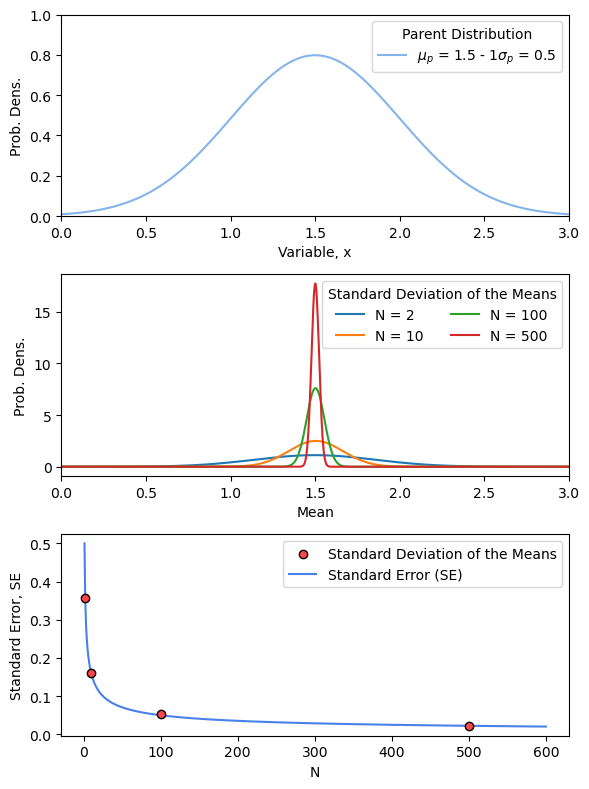

In [7]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

mean_value = 1.5
std_dev = 0.5
dist = stats.norm(loc=mean_value, scale=std_dev) 
x = np.linspace(0, 3, 1000)
fig = plt.figure(figsize=(6,8))

# Distribution of the Random Variable based on the normal PDF
pdf = dist.pdf(x)
ax1 = fig.add_subplot(3, 1, 1)
ax1.plot(x, pdf, color='#84b4e8', label =r'$\mu_p$ = 1.5 - 1$\sigma_p$ = 0.5')
ax1.set_xlim(0,3)
ax1.set_ylim(0,1)
ax1.set_xlabel('Variable, x')
ax1.set_ylabel('Prob. Dens.')
ax1.legend(title = 'Parent Distribution')

# Dependence of the SE on the Central Limit Theorem
ax2 = fig.add_subplot(3, 1, 2)
std_of_the_mean = []
ns = [2, 10, 100, 500]

for n in ns:
    # Mean Estimation Based on 1000 attempts using N values
    mean_dist = []
    for _ in range(1000):
        mean_dist.append(dist.rvs(size=n).mean())
    mean_dist = np.array(mean_dist)
    std_of_the_mean.append(mean_dist.std())
    normal = stats.norm(loc=mean_dist.mean(), scale=mean_dist.std())
    ax2.plot(x, normal.pdf(x), label='N = ' + str(n))     
ax2.set_xlim(0, 3)
ax2.set_xlabel('Mean')
ax2.set_ylabel('Prob. Dens.')
ax2.legend(title='Standard Deviation of the Means', ncol=2)   

# SE estimates and the empirically derived std of the Means
ax3 = fig.add_subplot(3, 1, 3)
ax3.scatter(ns, std_of_the_mean, color='#ff464a', edgecolor='#000000', label='Standard Deviation of the Means', zorder = 1)
n1 = np.linspace(1, 600, 600)
se = std_dev / np.sqrt(n1)
ax3.plot(n1 , se, c='#4881e9', label='Standard Error (SE)', zorder=0)
ax3.set_xlabel('N')
ax3.set_ylabel('Standard Error, SE')
ax3.legend()
fig.tight_layout()





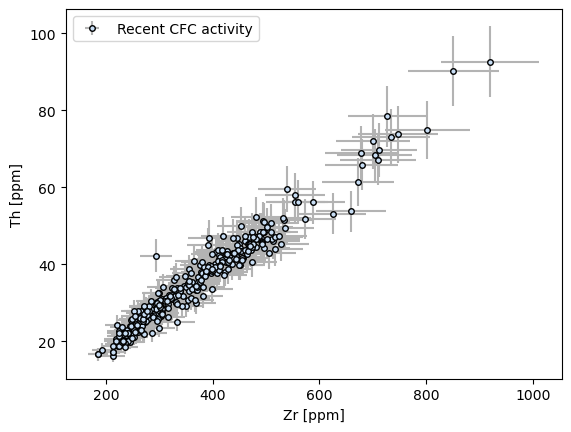

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

my_dataset1 = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name='Supp_traces')

x = my_dataset1.Zr
y = my_dataset1.Th
dx = my_dataset1.Zr * 0.1
dy = my_dataset1.Th * 0.1

fig, ax = plt.subplots()
ax.errorbar(x, y, xerr=dx, yerr=dy, marker='o', markersize=4, linestyle='', color='#c7ddf4', markeredgecolor='k', ecolor='0.7', label='Recent CFC activity')
ax.set_xlabel('Zr [ppm]')
ax.set_ylabel('Th [ppm]')
ax.legend(loc='upper left')



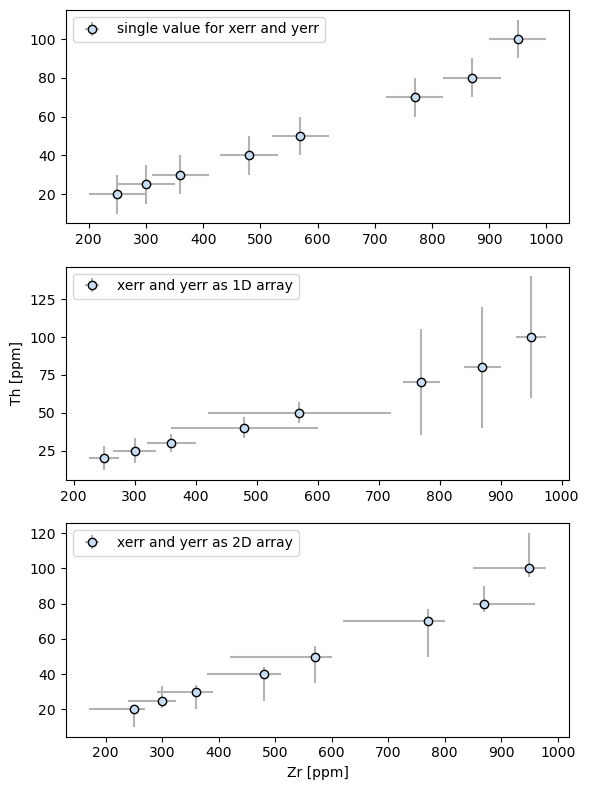

In [9]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([250,300,360,480,570,770,870,950])
y = np.array([20,25,30,40,50,70,80,100])


fig = plt.figure(figsize=(6,8))

# xerr and yerr reported as single value
dx = 50
dy = 10
ax1 = fig.add_subplot(3,1,1)
ax1.errorbar(x, y, xerr=dx, yerr=dy, marker='o', markersize=6, linestyle = '', color='#c7ddf4', markeredgecolor='k', ecolor='0.7', label='single value for xerr and yerr')
ax1.legend(loc='upper left')

# xerr and yerr reported as 1D array
dx = np.array([25,35,40,120,150,30,30,25])
dy = np.array([8,8,6,7,7,35,40,40])

ax2 = fig.add_subplot(3,1,2)
ax2.errorbar(x, y, xerr=dx, yerr=dy, marker='o', markersize=6, linestyle = '', color='#c7ddf4', markeredgecolor='k', ecolor='0.7', label='xerr and yerr as 1D array')
ax2.set_ylabel('Th [ppm]')
ax2.legend(loc='upper left')

# xerr and yerr reported as 2D array
dx = np.array([[80,60,70,100,150,150,20,100],[20,25,30,30,30,30,90,30]])
dy = np.array([[10,4,10,15,15,20,5,5],[2,8,4,4,6,7,10,20]])

ax3 = fig.add_subplot(3,1,3)
ax3.errorbar(x, y, xerr=dx, yerr=dy, marker='o', markersize=6, linestyle = '', color='#c7ddf4', markeredgecolor='k', ecolor='0.7',  label='xerr and yerr as 2D array')
ax3.set_xlabel('Zr [ppm]')
ax3.legend(loc='upper left')

fig.tight_layout()

Text(0, 0.5, 'Th [ppm]')

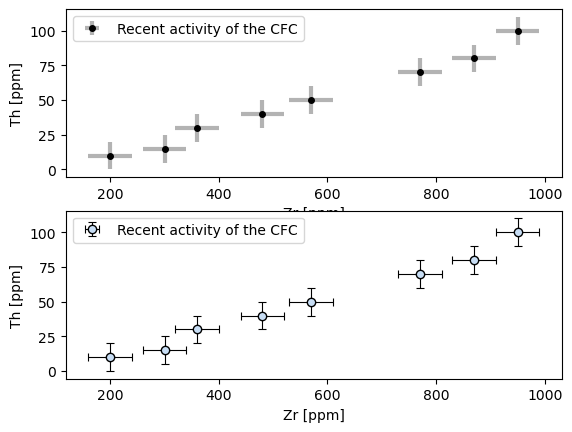

In [10]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([200, 300, 360, 480, 570, 770, 870, 950])
y = np.array([10, 15, 30, 40, 50, 70, 80, 100])
dx = 40
dy = 10

fig = plt.figure()
ax1 = fig.add_subplot(2, 1, 1)
ax1.errorbar(x, y, xerr=dx, yerr=dy, marker='o', markersize=4, linestyle='', color='k',  ecolor='0.7', elinewidth=3, capsize=0, label='Recent activity of the CFC')
ax1.legend(loc='upper left')
ax1.set_xlabel('Zr [ppm]')
ax1.set_ylabel('Th [ppm]')

ax2 = fig.add_subplot(2,1,2)
ax2.errorbar(x, y, xerr=dx, yerr=dy, marker='o', markersize=6, linestyle='', color='#c7ddf4', markeredgecolor='k', ecolor='k', elinewidth = 0.8, capthick=0.8, capsize=3, label='Recent activity of the CFC')
ax2.legend(loc='upper left')
ax2.set_xlabel('Zr [ppm]')
ax2.set_ylabel('Th [ppm]')





Text(0, 0.5, 'Th [ppm]')

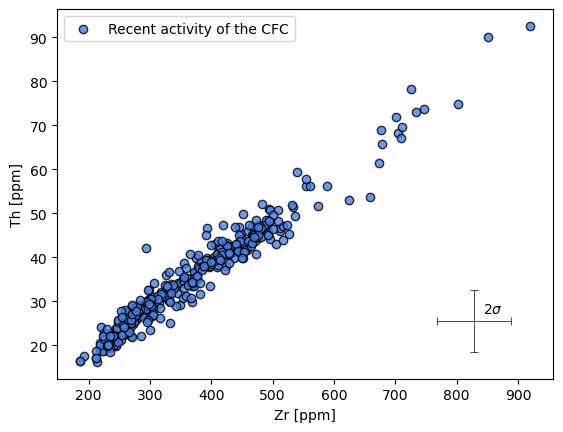

In [11]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_errorbar(x,y, dx, dy, xoffset, yoffset, text, ax):
    ax.errorbar(x,y, xerr=dx, yerr=dy, marker='', linestyle = '', elinewidth = .5, capthick=0.5,  ecolor='k', capsize=3)
    ax.text(x + xoffset, y + yoffset, text)

my_dataset1 = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name='Supp_traces')

x = my_dataset1.Zr
y = my_dataset1.Th

dx = 60
dy = 7

errorbar_x = x.max() - x.max() * 0.1
errorbar_y = y.min() + y.max() * 0.1

fig, ax1 = plt.subplots()
ax1.scatter(x, y, marker='o', color='#4881e9', edgecolor='k', alpha=0.8, label='Recent activity of the CFC')

plot_errorbar(errorbar_x, errorbar_y, dx, dy, dx/4, dy/4, r'2$\sigma$', ax1)

ax1.legend(loc='upper left')
ax1.set_xlabel('Zr [ppm]')
ax1.set_ylabel('Th [ppm]')


In [12]:
import numpy as np

def sum_ab(a, b, sigma_a, sigma_b):
    z = a + b
    sigma_z = np.sqrt(sigma_a**2 + sigma_b**2)
    return z, sigma_z

def division_ab(a, b, sigma_a, sigma_b):
    z = a / b
    sigma_z = z * np.sqrt((sigma_a/a)**2 + (sigma_b/b)**2)
    return z, sigma_z


In [13]:
import sympy as sym

a, b, sigma_a, sigma_b = sym.symbols("a b sigma_a sigma_b")

def symbolic_error_prop(func, val_a, val_sigma_a, val_b=0, val_sigma_b=0):
    
    z = sym.lambdify([a,b],func, 'numpy')
    sigma_z = sym.lambdify([a, b, sigma_a, sigma_b], sym.sqrt((sym.diff(func, a)**2 * sigma_a**2)+(sym.diff(func, b)**2 * sigma_b**2)), 'numpy')
    val_z = z(a=val_a, b=val_b)
    val_sigma_z = sigma_z(a=val_a, b=val_b, sigma_a=val_sigma_a, sigma_b=val_sigma_b)
    
    return val_z, val_sigma_z

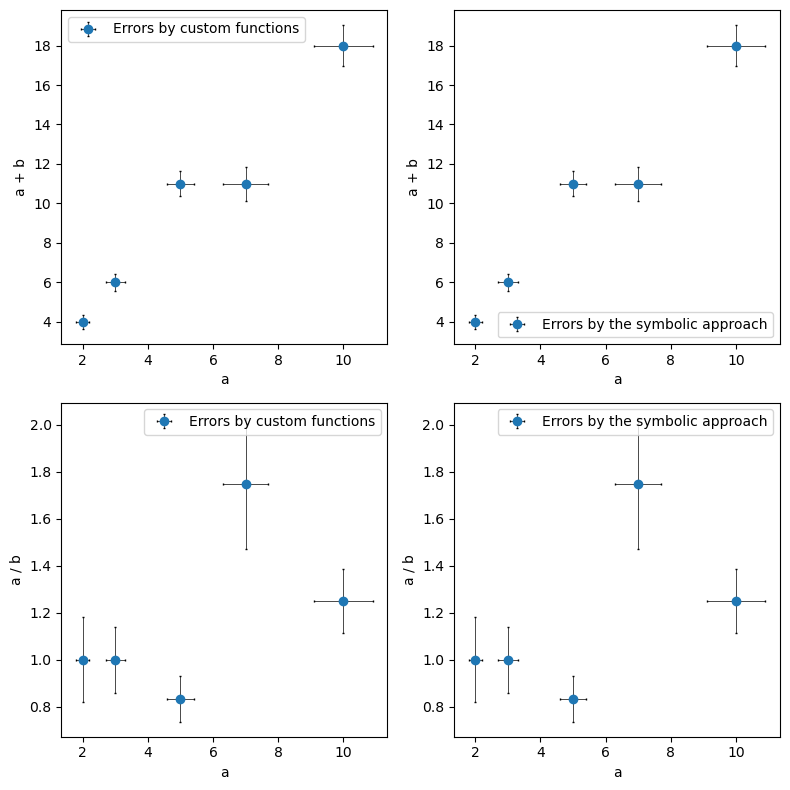

In [14]:
my_a = np.array([2, 3, 5, 7, 10]) 
my_sigma_a = np.array([0.2, 0.3, 0.4, 0.7, 0.9]) 
my_b = np.array([2, 3, 6, 4, 8])
my_sigma_b = np.array([0.3, 0.3, 0.5, 0.5, 0.5]) 

# errors propagated using custom functions
my_sum_ab_l, my_sigma_sum_ab_l = sum_ab(a=my_a, b=my_b, sigma_a=my_sigma_a, sigma_b=my_sigma_b)
my_division_ab_l, my_sigma_division_ab_l = division_ab(a=my_a, b=my_b, sigma_a=my_sigma_a, sigma_b=my_sigma_b)

# errors propagated using the symbolic approach
my_sum_ab_s, my_sigma_sum_ab_s = symbolic_error_prop(func=a+b, val_a=my_a, val_sigma_a=my_sigma_a, val_b=my_b, val_sigma_b=my_sigma_b)
my_division_ab_s, my_sigma_division_ab_s = symbolic_error_prop(func=a/b, val_a=my_a, val_sigma_a=my_sigma_a, val_b=my_b, val_sigma_b=my_sigma_b)

fig = plt.figure(figsize=(8, 8))
ax1 = fig.add_subplot(2, 2, 1)
ax1.errorbar(x=my_a, y=my_sum_ab_l, xerr=my_sigma_a, yerr=my_sigma_sum_ab_l, linestyle='', marker='o', ecolor='k', elinewidth=0.5, capsize=1, label='Errors by custom functions')
ax1.set_xlabel('a')
ax1.set_ylabel('a + b')
ax1.legend()
ax2 = fig.add_subplot(2, 2, 2)
ax2.errorbar(x=my_a, y=my_sum_ab_s, xerr=my_sigma_a, yerr=my_sigma_sum_ab_s, linestyle='', marker='o', ecolor='k', elinewidth=0.5, capsize=1, label='Errors by the symbolic approach')
ax2.set_xlabel('a')
ax2.set_ylabel('a + b')
ax2.legend()
ax3 = fig.add_subplot(2, 2, 3)
ax3.errorbar(x=my_a, y=my_division_ab_l, xerr=my_sigma_a, yerr=my_sigma_division_ab_l, linestyle='', marker='o', ecolor='k', elinewidth=0.5, capsize=1, label='Errors by custom functions')
ax3.set_xlabel('a')
ax3.set_ylabel('a / b')
ax3.legend()
ax4 = fig.add_subplot(2,2,4)
ax4.errorbar(x=my_a, y=my_division_ab_s, xerr=my_sigma_a, yerr=my_sigma_division_ab_s, linestyle='', marker ='o', ecolor='k', elinewidth=0.5, capsize=1, label='Errors by the symbolic approach')
ax4.set_xlabel('a')
ax4.set_ylabel('a / b')
ax4.legend()
fig.tight_layout()

Text(0.5, 0, 'La [ppm]')

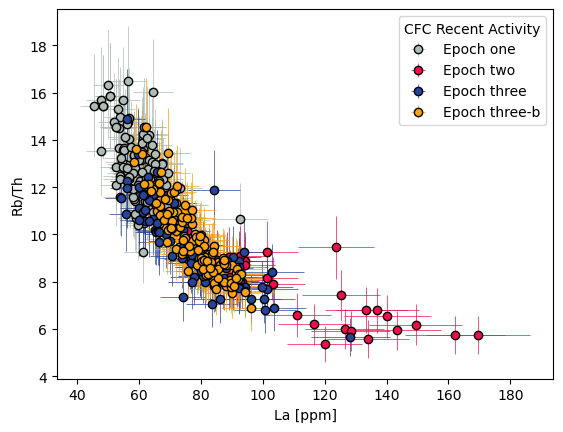

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sym

a, b, sigma_a, sigma_b = sym.symbols("a b sigma_a sigma_b")

def symbolic_error_prop(func, val_a, val_sigma_a,  val_b=0,  val_sigma_b=0):
    
    z = sym.lambdify([a, b], func, 'numpy')
    sigma_z = sym.lambdify([a, b, sigma_a, sigma_b], sym.sqrt((sym.diff(func, a)**2 * sigma_a**2)+(sym.diff(func,b)**2 * sigma_b**2)), 'numpy')
    val_z = z(a=val_a, b=val_b)
    val_sigma_z = sigma_z(a=val_a, b=val_b, sigma_a=val_sigma_a, sigma_b=val_sigma_b)
    
    return val_z, val_sigma_z

my_dataset = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name='Supp_traces')

ratio_y, sigma_ratio_y = symbolic_error_prop(a/b, val_a=my_dataset.Rb, val_sigma_a=my_dataset.Rb*0.1, val_b=my_dataset.Th,  val_sigma_b=my_dataset.Th*0.1)

my_dataset['Rb_Th'] = ratio_y
my_dataset['Rb_Th_1s'] = sigma_ratio_y 

epochs = ['one','two','three','three-b']
colors = ['#afbbb5', '#f10e4a', '#27449c', '#f9a20e']

fig, ax = plt.subplots()
for epoch, color in zip(epochs, colors):
    my_data = my_dataset[(my_dataset.Epoch == epoch)]
    ax.errorbar(x=my_data.La, y=my_data.Rb_Th, xerr=my_data.La*0.1, yerr=my_data.Rb_Th_1s, linestyle='', markerfacecolor= color, markersize=6, marker='o', markeredgecolor='k', ecolor=color, elinewidth=0.5, capsize=0, label="Epoch " + epoch)

ax.legend(title='CFC Recent Activity')
ax.set_ylabel('Rb/Th')
ax.set_xlabel('La [ppm]')


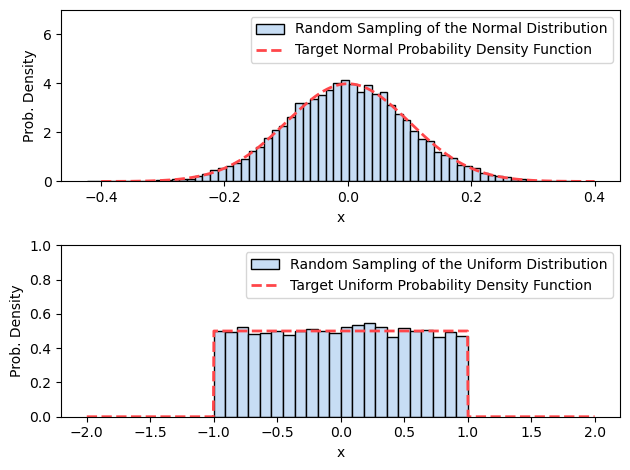

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def normal_pdf(x, mu, sigma):
    pdf = 1/(sigma * np.sqrt(2*np.pi)) * np.exp(-(x-mu)**2 / (2*sigma**2))
    return pdf

def unifrom_pdf(x, a, b):
    pdf = np.piecewise(x, [(x>=a) & (x<=b), (x<a) & (x>b)], [1/(b-a), 0])
    return pdf

# Random sampling of a normal distribution
my_mu, my_sigma = 0, 0.1 # mean and standard deviation
sn = np.random.default_rng().normal(loc=my_mu, scale=my_sigma, size=10000)
fig = plt.figure()
ax1 = fig.add_subplot(2, 1, 1)
ax1.hist(sn, density=True, bins='auto', edgecolor='k', color='#c7ddf4', label='Random Sampling of the Normal Distribution')
my_xn = np.linspace(my_mu - 4 * my_sigma, my_mu + 4 * my_sigma, 1000)
my_yn = normal_pdf(x=my_xn, mu=my_mu, sigma=my_sigma)
ax1.plot(my_xn, my_yn,linewidth=2, linestyle='--', color='#ff464a', label='Target Normal Probability Density Function')
ax1.set_ylim(0.0, 7.0)
ax1.set_xlabel('x')
ax1.set_ylabel('Prob. Density')
ax1.legend()

# Random sampling of a uniform distribution
my_a, my_b = -1, 1 # lower and upper bound of the uniform distribution
su = np.random.default_rng().uniform(low=my_a, high=my_b, size=10000)
ax2 = fig.add_subplot(2, 1, 2)
ax2.hist(su, density=True, bins='auto', edgecolor='k', color='#c7ddf4', label='Random Sampling of the Uniform Distribution')
my_xu = np.linspace(-2, 2, 1000)
my_yu = unifrom_pdf(x=my_xu, a=my_a, b=my_b)
ax2.plot(my_xu, my_yu, linewidth=2, linestyle='--', color='#ff464a', label='Target Uniform Probability Density Function')
ax2.set_ylim(0, 1)
ax2.set_xlabel('x')
ax2.set_ylabel('Prob. Density')
ax2.legend()

fig.tight_layout()


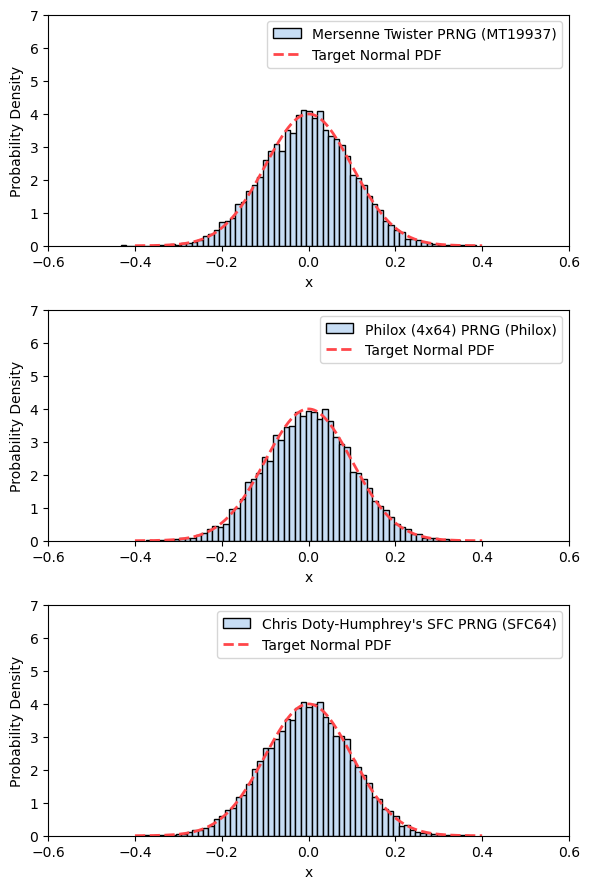

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def normal_pdf(x, mu, sigma):
    pdf = 1/(sigma * np.sqrt(2 * np.pi)) * np.exp( - (x - mu)**2 / (2 * sigma**2))
    return pdf

fig = plt.figure(figsize=(6,9))

# Random sampling of a normal distribution
my_mu, my_sigma = 0, 0.1 # mean and standard deviation

bit_generators = [np.random.MT19937(), np.random.Philox(), np.random.SFC64()]
names = ['Mersenne Twister PRNG (MT19937)', 'Philox (4x64) PRNG (Philox)', 'Chris Doty-Humphrey\'s SFC PRNG (SFC64)']
indexes = [1,2,3]

for bit_generator, name, index in zip(bit_generators, names, indexes):
    sn = np.random.Generator(bit_generator).normal(loc = my_mu, scale = my_sigma, size = 10000)
    ax = fig.add_subplot(3, 1, index)
    ax.hist(sn, density=True, bins='auto', edgecolor='k', color='#c7ddf4', label=name)
    my_xn = np.linspace(my_mu - 4 * my_sigma, my_mu + 4 * my_sigma, 1000)
    my_yn = normal_pdf(x=my_xn, mu=my_mu, sigma=my_sigma)
    ax.plot(my_xn, my_yn, linewidth=2, linestyle='--', color='#ff464a', label ='Target Normal PDF')
    ax.set_ylim(0.0, 7.0)
    ax.set_xlim(my_mu - 6 * my_sigma, my_mu + 6 * my_sigma)
    ax.set_xlabel('x')
    ax.set_ylabel('Probability Density')
    ax.legend()

fig.tight_layout()



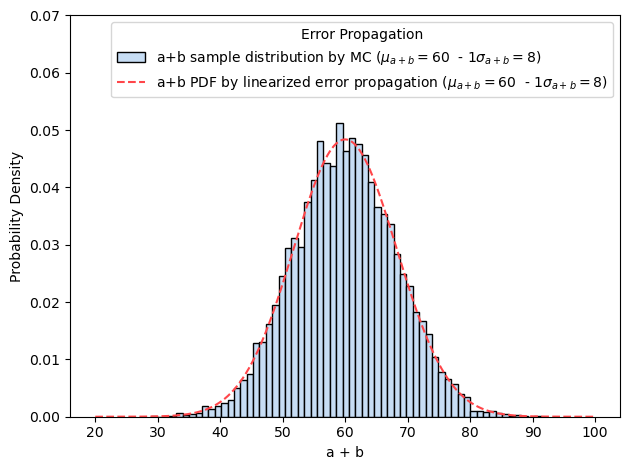

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian(x, mean, std):
    return 1/(np.sqrt(2*np.pi*std**2))*np.exp(-0.5*(((x - mean)**2)/(std**2)))

my_a, my_sigma_a = 40, 8 
my_b, my_sigma_b = 20, 2 

n = 10000
a_normal = np.random.default_rng().normal(my_a, my_sigma_a, n)
b_normal = np.random.default_rng().normal(my_b, my_sigma_b, n)   

# Linearized Method
my_sum_ab_l, my_sigma_sum_ab_l = sum_ab(a=my_a, b=my_b, sigma_a=my_sigma_a, sigma_b=my_sigma_b)
my_x = np.linspace(20, 100, 1000)
my_sum_ab_PDF = gaussian(x=my_x, mean=my_sum_ab_l, std=my_sigma_sum_ab_l)

# Monte Carlo estimation
my_sum_ab_mc =  a_normal + b_normal
my_sum_ab_mc_mean = my_sum_ab_mc.mean()
my_sigma_sum_ab_mc_std = my_sum_ab_mc.std()
 
fig, ax = plt.subplots()
ax.hist(my_sum_ab_mc, bins='auto', color='#c7ddf4', edgecolor='k', density=True, label= r'a+b sample distribution by MC ($\mu_{a+b} = $' + "{:.0f}".format(my_sum_ab_mc_mean) + r'  - 1$\sigma_{a+b} = $' + "{:.0f}".format(my_sigma_sum_ab_mc_std) + ')')
ax.plot(my_x, my_sum_ab_PDF, color='#ff464a', linestyle='--', label=r'a+b PDF by linearized error propagation ($\mu_{a+b} = $' + "{:.0f}".format(my_sum_ab_l) + r'  - 1$\sigma_{a+b} = $' + "{:.0f}".format(my_sigma_sum_ab_l) + ')')
ax.set_xlabel('a + b')
ax.set_ylabel('Probability Density')
ax.legend(title='Error Propagation')
ax.set_ylim(0,0.07)

fig.tight_layout()


